# Find the Perimeter (Exterior Points) of a collection of shapefile points

In [1]:
## Imports

import os
import collections

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from shapely.geometry import Point, MultiPoint
from shapely import concave_hull

ERROR 1: PROJ: proj_create_from_database: Open of /media/Work/miniforge3/envs/dorn/share/proj failed


In [2]:
## Environment Config

ntbk_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(ntbk_dir,'..'))
data_dir = os.path.join(root_dir,'data')
shap_dir = os.path.join(data_dir,'shapefiles')

In [3]:
## Load Shapefiles

RozaFullBasin  = gpd.read_file(os.path.join(shap_dir,'RozaFullBasin', 'RozaFullBasin.shp' ))
RozaSubBasin01 = gpd.read_file(os.path.join(shap_dir,'RozaSubBasin01','RozaSubBasin01.shp'))
RozaSubBasin02 = gpd.read_file(os.path.join(shap_dir,'RozaSubBasin02','RozaSubBasin02.shp'))
RozaSubBasin03 = gpd.read_file(os.path.join(shap_dir,'RozaSubBasin03','RozaSubBasin03.shp'))

In [4]:
## Extract the Lat/Lon Points as a list of Coord objects

RozaFullBasin_ll= pd.DataFrame({'Lat':RozaFullBasin.Lat,  'Lon':RozaFullBasin.Lon })
RozaSubBasin01_ll=pd.DataFrame({'Lat':RozaSubBasin01.Lat, 'Lon':RozaSubBasin01.Lon})
RozaSubBasin02_ll=pd.DataFrame({'Lat':RozaSubBasin02.Lat, 'Lon':RozaSubBasin02.Lon})
RozaSubBasin03_ll=pd.DataFrame({'Lat':RozaSubBasin03.Lat, 'Lon':RozaSubBasin03.Lon})

Coord = collections.namedtuple('Coord', ['Lat', 'Lon'])

_records=list(map(lambda rr: Coord(**rr), RozaSubBasin01_ll.to_dict(orient='records'))) +\
         list(map(lambda rr: Coord(**rr), RozaSubBasin02_ll.to_dict(orient='records'))) +\
         list(map(lambda rr: Coord(**rr), RozaSubBasin03_ll.to_dict(orient='records'))) +\
         list(map(lambda rr: Coord(**rr), RozaFullBasin_ll.to_dict (orient='records')))

In [5]:
## Create Point Collection from extracted points and calculate the Concave Hull

coords=concave_hull(MultiPoint([Point(x.Lon, x.Lat) for x in _records]), 0.005).exterior.coords.xy

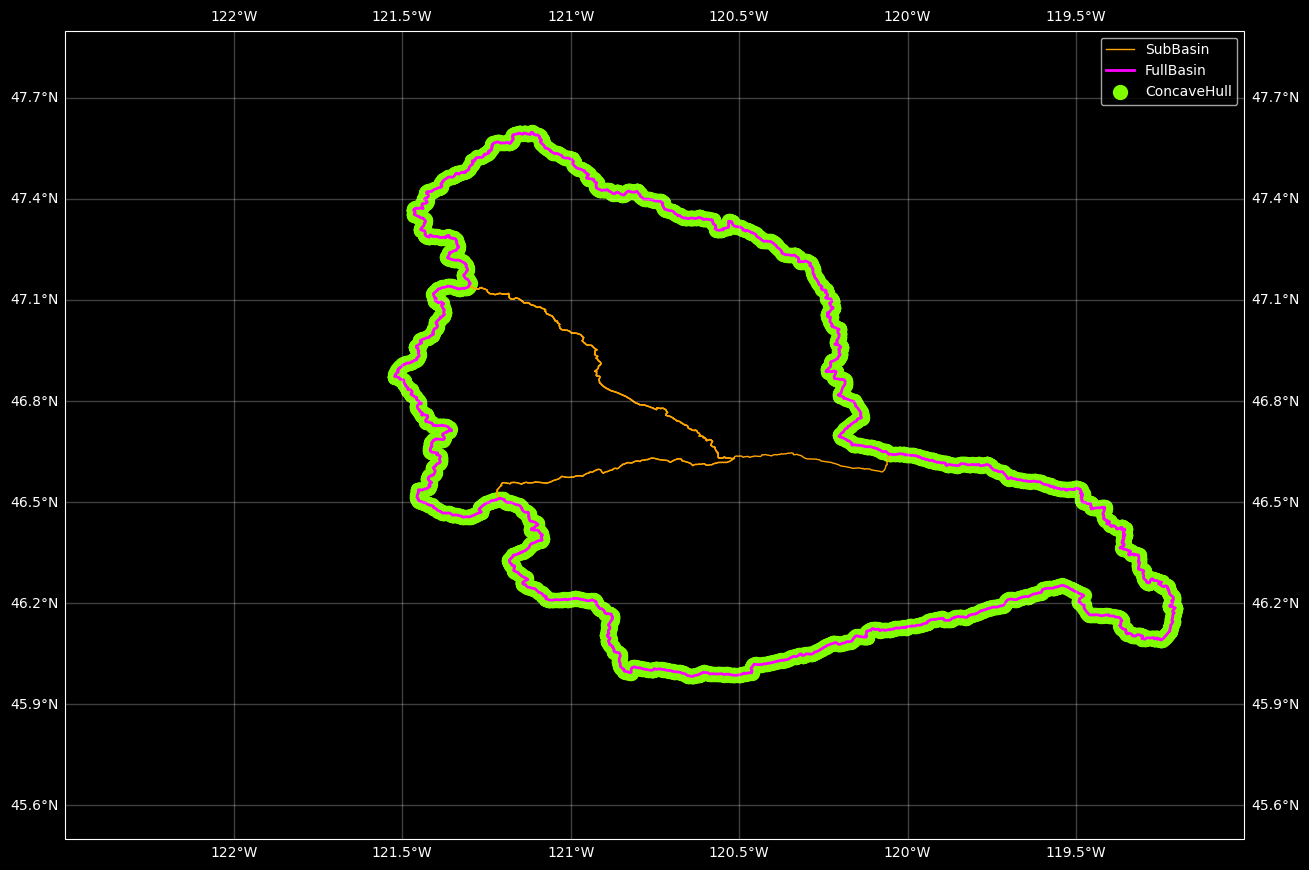

In [6]:
## Plot the original shapefile objects and calculated Concave Hull for comparison

plt.style.use('dark_background')

fig = plt.figure(figsize=(18.5, 10.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-122.5,-119, 45.5, 47.9), crs=ccrs.PlateCarree())

ax.scatter(coords[0].tolist(), coords[1].tolist(), linewidth=5, color='chartreuse', label='ConcaveHull')
ax.plot(RozaSubBasin01.Lon.to_list(), RozaSubBasin01.Lat.to_list(), linewidth=1, color='orange')
ax.plot(RozaSubBasin02.Lon.to_list(), RozaSubBasin02.Lat.to_list(), linewidth=1, color='orange')
ax.plot(RozaSubBasin02.Lon.to_list(), RozaSubBasin02.Lat.to_list(), linewidth=1, color='orange',  label='SubBasin' )
ax.plot(RozaFullBasin.Lon.to_list(),  RozaFullBasin.Lat.to_list(),  linewidth=2, color='magenta', label='FullBasin')

ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    dms=False,
    x_inline=False,
    y_inline=False,
    linewidth=1,
    color="w",
    alpha=0.25,
    zorder=4)

ax.legend()

plt.show()